In [2]:
import pandas as pd 
import numpy as np 
import seaborn as sns 
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv(r'C:\Users\ANUBHAV\Data_Analytics\DAP\EDA\Datasets\train (1).csv')
df.head() 

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


# Why do EDA : 

 - Model building.
 - Analysis and reporting.
 - Validate assumptions.
 - Handelling missing values.
 - feature engineering.
 - detecting outliers.


# NOTE: 
- EDA is an iterative process. 


# STEP : 1 
- Define the column type.
- group them in three different catogeries.

--> Numerical : Age , Fare , PassengerId .


--> Categorical : Survived , Pclass , Sex , SibSp ,Parch , Embarked 


--> Mixed : Name , Ticket , Cabin.



# STEP : 2 

 -- > :: Performed given Operations :  
[ These operations are performed multiple times in loop untill you reached final conclusions ].


1. Univariate Analysis.
2. Bivariate Analysis.
3. Multivariate Analysis.
4. Feature Engineering.
5. Finding Outliers.
6. Handelling missing Values.















   

# 1. Univariate Analysis : 

-- Univariate analysis focuses on analyzing each feature(Column) in the dataset independently.

-> **Distribution analysis**: The distribution of each feature is examined to identify its shape, central tendency, and dispersion.

-> **Identifying potential issues**: Univariate analysis helps in identifying potential problems with the data such as outliers, skewness, and missing values.






#### The shape of a data distribution refers to its overall pattern or form as it is represented on a graph. Some common shapes of data distributions include:

- **Normal Distribution**: A symmetrical and bell-shaped distribution where the mean, median, and mode are equal and the majority of the data falls in the middle of the distribution with gradually decreasing frequencies towards the tails.

- **Skewed Distribution**: A distribution that is not symmetrical, with one tail being longer than the other. It can be either positively skewed (right-skewed) or negatively skewed (left-skewed).

- **Bimodal Distribution**: A distribution with two peaks or modes.

- **Uniform Distribution**: A distribution where all values have an equal chance of occurring.

The shape of the data distribution is important in identifying the presence of outliers, skewness, and the type of statistical tests and models that can be used for further analysis.




In [25]:
# Steps of doing the univariate analysis on Numerical analysis : 

# Age Column : 



** Conclusions ** :  

1. Age is normally(almost) distributed,
2. 20% of the values are missing,
3. There are some outliers.







In [4]:
df['Age'].describe()

count    714.000000
mean      29.699118
std       14.526497
min        0.420000
25%       20.125000
50%       28.000000
75%       38.000000
max       80.000000
Name: Age, dtype: float64

<Axes: ylabel='Frequency'>

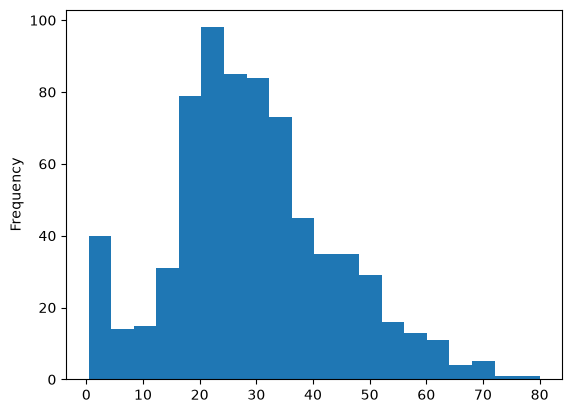

In [5]:
df['Age'].plot(kind = 'hist' , bins = 20)

<Axes: ylabel='Density'>

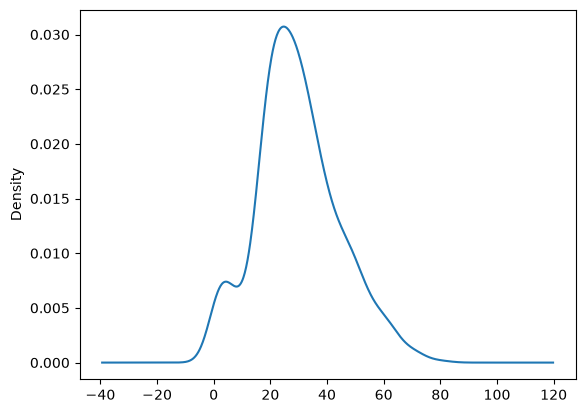

In [7]:
df['Age'].plot(kind = 'kde')


In [8]:
# normal distribution : 

df['Age'].skew()

np.float64(0.38910778230082704)

<Axes: >

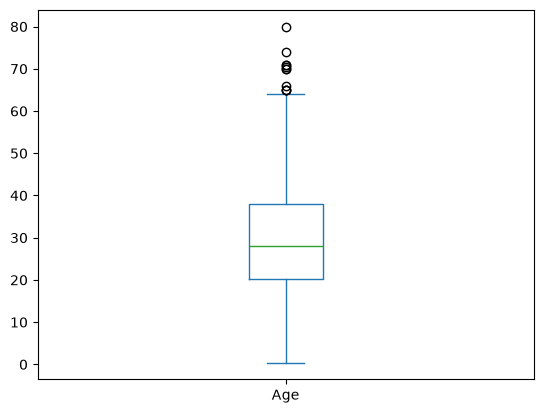

In [9]:
# box plot : tells us about the outliers. 


df['Age'].plot(kind = 'box')

In [10]:
df[df['Age']  > 65 ]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
33,34,0,2,"Wheadon, Mr. Edward H",male,66.0,0,0,C.A. 24579,10.5000,NaN,S
96,97,0,1,"Goldschmidt, Mr. George B",male,71.0,0,0,PC 17754,34.6542,A5,C
116,117,0,3,"Connors, Mr. Patrick",male,70.5,0,0,370369,7.7500,NaN,Q
493,494,0,1,"Artagaveytia, Mr. Ramon",male,71.0,0,0,PC 17609,49.5042,NaN,C
630,631,1,1,"Barkworth, Mr. Algernon Henry Wilson",male,80.0,0,0,27042,30.0000,A23,S
672,673,0,2,"Mitchell, Mr. Henry Michael",male,70.0,0,0,C.A. 24580,10.5000,NaN,S
745,746,0,1,"Crosby, Capt. Edward Gifford",male,70.0,1,1,WE/P 5735,71.0000,B22,S
851,852,0,3,"Svensson, Mr. Johan",male,74.0,0,0,347060,7.7750,NaN,S


In [14]:
# checking the missing values in age column : 

df['Age'].isnull().sum()  #--> 177

df['Age'].isnull().sum() / len(df['Age'])


np.float64(0.19865319865319866)

# Fare Column:


** Conclusions** :  

1. The data is highly postively skewed.
2. Fare column actually contain the group fare and not the individual fare ( this might be an issue ).
3. We need to perform the feature Engineering and create a new column called individual fare.
   


In [15]:
df['Fare'].describe()

count    891.000000
mean      32.204208
std       49.693429
min        0.000000
25%        7.910400
50%       14.454200
75%       31.000000
max      512.329200
Name: Fare, dtype: float64

<Axes: ylabel='Frequency'>

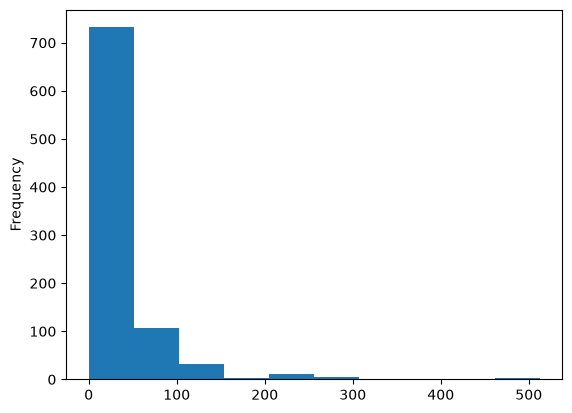

In [16]:
df['Fare'].plot(kind = 'hist')

<Axes: ylabel='Density'>

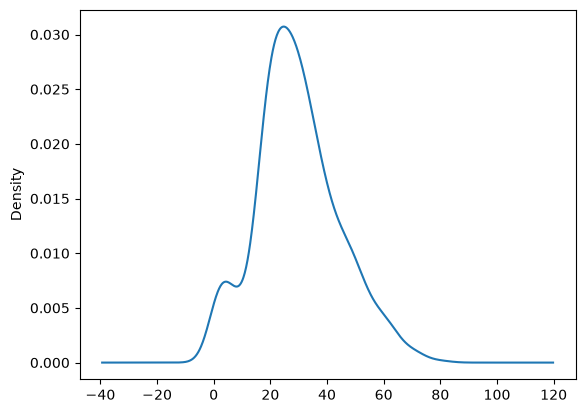

In [17]:
df['Age'].plot(kind = 'kde')

In [18]:
# checking skewness : 

df['Fare'].skew()  #--> 4.787 [ highly positivly skewwed ] 

#--> we have to carefull while performing the stastical analysis!

np.float64(4.787316519674893)

<Axes: >

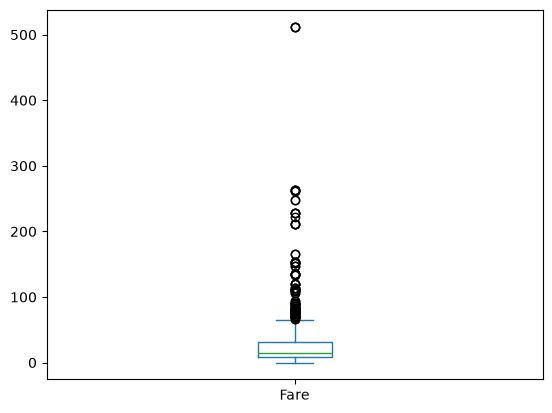

In [19]:
# Checking outliers : 

df['Fare'].plot(kind = 'box')

In [22]:
df[df['Fare'] > 250 ]



,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
27,28,0,1,"Fortune, Mr. Charles Alexander",male,19.0,3,2,19950,263.0000,C23 C25 C27,S
88,89,1,1,"Fortune, Miss. Mabel Helen",female,23.0,3,2,19950,263.0000,C23 C25 C27,S
258,259,1,1,"Ward, Miss. Anna",female,35.0,0,0,PC 17755,512.3292,NaN,C
311,312,1,1,"Ryerson, Miss. Emily Borie",female,18.0,2,2,PC 17608,262.3750,B57 B59 B63 B66,C
341,342,1,1,"Fortune, Miss. Alice Elizabeth",female,24.0,3,2,19950,263.0000,C23 C25 C27,S
438,439,0,1,"Fortune, Mr. Mark",male,64.0,1,4,19950,263.0000,C23 C25 C27,S
679,680,1,1,"Cardeza, Mr. Thomas Drake Martinez",male,36.0,0,1,PC 17755,512.3292,B51 B53 B55,C
737,738,1,1,"Lesurer, Mr. Gustave J",male,35.0,0,0,PC 17755,512.3292,B101,C
742,743,1,1,"Ryerson, Miss. Susan Parker ""Suzette""",female,21.0,2,2,PC 17608,262.3750,B57 B59 B63 B66,C


In [23]:
df['Fare'].isnull().sum()

np.int64(0)

In [24]:
# Steps of doing the univariate analysis on categorical analysis : 
